## ALS Recommendation System for Student Projects

This notebook implements an Alternating Least Squares (ALS) recommendation system for student projects using **Custom ALS implementation** specifically designed for **explicit ratings** (1-5 scale).

## Setup
- **Items**: Project titles in Russian from data.xlsx
- **Interactions**: User ratings from artificial_profiles_scores.pkl
- **Library**: Custom ALS - designed for explicit ratings (1-5 scale)

In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

from als_explicit import ExplicitALS
import warnings

warnings.filterwarnings("ignore")

## Load Data

In [2]:
df = pd.read_excel("data_clean.xlsx", header=0)
df = df.fillna("")
df.drop_duplicates(inplace=True)
print(f"Total projects: {len(df)}")

Total projects: 1187


In [3]:
df.head()

,title_rus,title_eng,annotation,description
0,Исследование приоритетов и механизмов реализац...,Study of Priorities and Mechanisms for Impleme...,Работа международных фондов (доноров) должна п...,"Согласно определению международных фондов, про..."
1,Антрополе - научно-популярный видео-подкаст о ...,Anthropole is a Popular Science Video Podcast ...,"\tАнтрополе - научно-популярный проект, в рамк...","Социальное знание близко и интересно обществу,..."
2,"Разработка, создание и ведение сайта, посвящен...","Design, Development and Implementation of a We...",Художественное образование и творчество художн...,Тема обучения арабских художников в художестве...
3,Перевод с английского языка коллективной моног...,Translation from English of the collective mon...,"Коллективная монография, авторы которой являют...","Коллективная монография, авторы которой являют..."
4,Сеть военно-политических союзов в Евразии: баз...,Network of Military in Eurasia: a Database,Проект посвящен изучению сети военно-политичес...,Проект посвящен анализу истории существования ...


In [4]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    interactions = pickle.load(f)

print("Interaction statistics per user:")
for user, ratings in interactions.items():
    valid_ratings = [r for r in ratings.values() if r is not None]
    print(f"  {user}: {len(ratings)} total, {len(valid_ratings)} rated")

Interaction statistics per user:
  international_relations_specialist: 18 total, 18 rated
  sociology_and_cultural_studies_researcher: 19 total, 19 rated
  economics_macro_analyst: 16 total, 16 rated
  linguistics_and_translation_specialist: 15 total, 15 rated
  software_engineer_and_developer: 15 total, 15 rated
  marketing_strategist: 17 total, 17 rated
  cultural_studies_researcher: 8 total, 8 rated
  education_specialist_and_developer: 11 total, 11 rated
  historical_researcher: 10 total, 10 rated
  media_strategist_and_cultural_analyst: 10 total, 10 rated
  legal_researcher_and_policy_analyst: 12 total, 12 rated
  psychology_researcher: 13 total, 13 rated
  geopolitics_analyst: 11 total, 11 rated
  literature_scholar: 7 total, 7 rated
  natural_language_processor: 10 total, 10 rated
  finance_strategist: 9 total, 9 rated
  ai_language_and_education_specialist: 4 total, 4 rated
  political_science_expert: 7 total, 7 rated
  pedagogy_specialist: 7 total, 7 rated
  project_manager_an

## Build User-Item Matrix

In [5]:
project_titles = df["title_rus"].tolist()
user_ids = list(interactions.keys())

print(f"Number of users: {len(user_ids)}")
print(f"Number of projects: {len(project_titles)}")

Number of users: 32
Number of projects: 1187


In [6]:
num_users = len(user_ids)
num_items = len(project_titles)

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
item_to_idx = {item: idx for idx, item in enumerate(project_titles)}

row_indices = []
col_indices = []
ratings = []

for user, user_ratings in interactions.items():
    user_idx = user_to_idx[user]
    for project_title, rating in user_ratings.items():
        if rating is not None and rating > 2 and project_title in item_to_idx:
            item_idx = item_to_idx[project_title]
            row_indices.append(user_idx)
            col_indices.append(item_idx)
            ratings.append(rating)

rating_matrix = csr_matrix(
    (ratings, (row_indices, col_indices)), shape=(num_users, num_items)
)

print(f"Rating matrix shape: {rating_matrix.shape}")
print(f"Number of ratings: {len(ratings)}")
print(f"Sparsity: {len(ratings) / (num_users * num_items) * 100:.2f}%")

Rating matrix shape: (32, 1187)
Number of ratings: 299
Sparsity: 0.79%


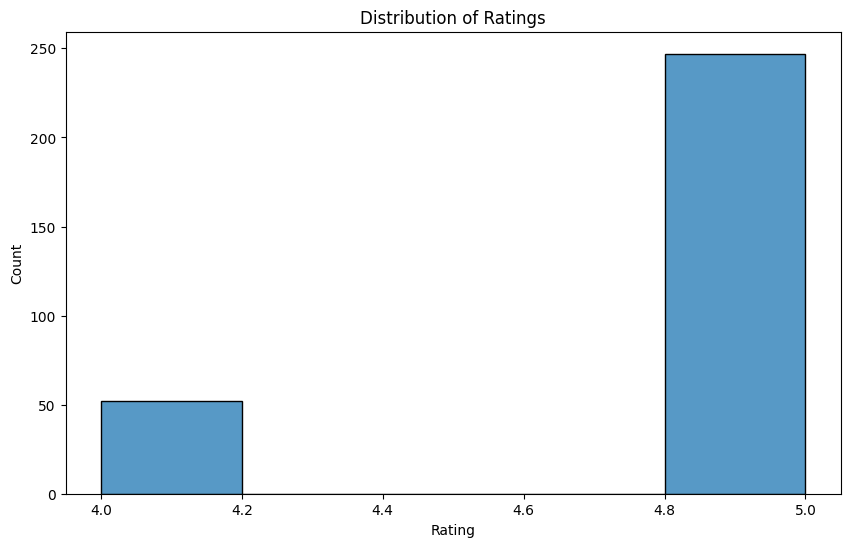

Rating statistics:
  Mean: 4.83
  Std: 0.38
  Min: 4
  Max: 5


In [7]:
rating_values = [r for r in ratings]
plt.figure(figsize=(10, 6))
sns.histplot(rating_values, bins=5, kde=False)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

print(f"Rating statistics:")
print(f"  Mean: {np.mean(rating_values):.2f}")
print(f"  Std: {np.std(rating_values):.2f}")
print(f"  Min: {np.min(rating_values)}")
print(f"  Max: {np.max(rating_values)}")

## Split Data into Train and Test Sets

In [8]:
from sklearn.model_selection import train_test_split

rows, cols = rating_matrix.nonzero()
n_ratings = len(rows)

rating_indices = np.arange(n_ratings)

train_indices, test_indices = train_test_split(
    rating_indices, test_size=0.2, random_state=42, stratify=rows
)

train_rows = rows[train_indices]
train_cols = cols[train_indices]
train_ratings_data = np.array(
    [rating_matrix[train_rows[i], train_cols[i]] for i in range(len(train_indices))]
)

test_rows = rows[test_indices]
test_cols = cols[test_indices]
test_ratings_data = np.array(
    [rating_matrix[test_rows[i], test_cols[i]] for i in range(len(test_indices))]
)

train_matrix = csr_matrix(
    (train_ratings_data, (train_rows, train_cols)), shape=(num_users, num_items)
)

print(f"Original ratings: {n_ratings}")
print(
    f"Training ratings: {len(train_indices)} ({len(train_indices)/n_ratings*100:.1f}%)"
)
print(f"Test ratings: {len(test_indices)} ({len(test_indices)/n_ratings*100:.1f}%)")

train_users = set(train_rows)
test_users = set(test_rows)
print(f"\nUsers in training set: {len(train_users)}")
print(f"Users in test set: {len(test_users)}")

Original ratings: 299
Training ratings: 239 (79.9%)
Test ratings: 60 (20.1%)

Users in training set: 32
Users in test set: 31


In [9]:
model = ExplicitALS(
    n_factors=5,
    n_iterations=64,
    user_reg=5,
    item_reg=5,
    early_stopping_rounds=4,
    random_state=42,
)

print("Custom ALS model initialized with anti-overfitting settings:")
print(f"  - Factors: {model.n_factors}")
print(f"  - Max iterations: {model.n_iterations}")
print(f"  - User regularization: {model.user_reg}")
print(f"  - Item regularization: {model.item_reg}")
print(f"  - Early stopping rounds: {model.early_stopping_rounds}")

Custom ALS model initialized with anti-overfitting settings:
  - Factors: 5
  - Max iterations: 64
  - User regularization: 5
  - Item regularization: 5
  - Early stopping rounds: 4


In [10]:
final_train_indices, val_indices = train_test_split(
    np.arange(len(train_indices)), test_size=0.2, random_state=42, stratify=train_rows
)

final_train_rows = train_rows[final_train_indices]
final_train_cols = train_cols[final_train_indices]
final_train_ratings_data = np.array(
    [
        rating_matrix[final_train_rows[i], final_train_cols[i]]
        for i in range(len(final_train_indices))
    ]
)

val_rows = train_rows[val_indices]
val_cols = train_cols[val_indices]
val_ratings_data = np.array(
    [rating_matrix[val_rows[i], val_cols[i]] for i in range(len(val_indices))]
)

final_train_matrix = csr_matrix(
    (final_train_ratings_data, (final_train_rows, final_train_cols)),
    shape=(num_users, num_items),
)
val_matrix = csr_matrix(
    (val_ratings_data, (val_rows, val_cols)), shape=(num_users, num_items)
)

print(f"Final training data: {len(final_train_indices)} ratings")
print(f"Validation data: {len(val_indices)} ratings")
print(f"Test data: {len(test_indices)} ratings")

print("\nUser distribution across splits:")
for user_idx in range(num_users):
    train_count = np.sum(final_train_rows == user_idx)
    val_count = np.sum(val_rows == user_idx)
    test_count = np.sum(test_rows == user_idx)
    print(
        f"  {user_ids[user_idx]}: Train={train_count}, Val={val_count}, Test={test_count}"
    )

Final training data: 191 ratings
Validation data: 48 ratings
Test data: 60 ratings

User distribution across splits:
  international_relations_specialist: Train=11, Val=3, Test=4
  sociology_and_cultural_studies_researcher: Train=12, Val=3, Test=4
  economics_macro_analyst: Train=10, Val=3, Test=3
  linguistics_and_translation_specialist: Train=10, Val=2, Test=3
  software_engineer_and_developer: Train=10, Val=2, Test=3
  marketing_strategist: Train=10, Val=3, Test=4
  cultural_studies_researcher: Train=5, Val=1, Test=2
  education_specialist_and_developer: Train=7, Val=2, Test=2
  historical_researcher: Train=6, Val=2, Test=2
  media_strategist_and_cultural_analyst: Train=6, Val=2, Test=2
  legal_researcher_and_policy_analyst: Train=7, Val=2, Test=3
  psychology_researcher: Train=8, Val=2, Test=3
  geopolitics_analyst: Train=7, Val=2, Test=2
  literature_scholar: Train=5, Val=1, Test=1
  natural_language_processor: Train=6, Val=2, Test=2
  finance_strategist: Train=6, Val=1, Test=2
  

In [11]:
print("Training Custom ALS model with early stopping...")
model.fit(final_train_matrix, validation_matrix=val_matrix)

print("\nTraining completed!")
print(f"Model user factors shape: {model.user_factors.shape}")
print(f"Model item factors shape: {model.item_factors.shape}")

print(f"\nTraining stopped after {len(model.training_history)} iterations")

Training Custom ALS model with early stopping...
Iteration 0, Train MSE: 22.4746, Val MSE: 23.8349
Iteration 2, Train MSE: 4.9012, Val MSE: 23.4515
Iteration 4, Train MSE: 4.0988, Val MSE: 23.7387
Early stopping at iteration 5
Training completed after 6 iterations

Training completed!
Model user factors shape: (32, 5)
Model item factors shape: (1187, 5)

Training stopped after 6 iterations


In [12]:
def predict_for_pairs(model, rows, cols):
    """Predict ratings for specific user-item pairs"""
    predictions = np.zeros(len(rows))
    for idx, (u, i) in enumerate(zip(rows, cols)):
        predictions[idx] = model.user_factors[u] @ model.item_factors[i]
    return predictions


train_predictions = predict_for_pairs(model, final_train_rows, final_train_cols)
train_mse = mean_squared_error(final_train_ratings_data, train_predictions)
train_rmse = np.sqrt(train_mse)

print("Training Set Performance:")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")

val_predictions = predict_for_pairs(model, val_rows, val_cols)
val_mse = mean_squared_error(val_ratings_data, val_predictions)
val_rmse = np.sqrt(val_mse)

print("\nValidation Set Performance:")
print(f"  MSE: {val_mse:.4f}")
print(f"  RMSE: {val_rmse:.4f}")

test_predictions = predict_for_pairs(model, test_rows, test_cols)
test_mse = mean_squared_error(test_ratings_data, test_predictions)
test_rmse = np.sqrt(test_mse)

print("\nTest Set Performance:")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")

print(f"\nOverfitting Analysis:")
print(f"  Val/Train RMSE ratio: {val_rmse/train_rmse:.2f}")
print(f"  Test/Train RMSE ratio: {test_rmse/train_rmse:.2f}")
print(f"  Test/Val RMSE ratio: {test_rmse/val_rmse:.2f}")

if test_rmse / train_rmse < 1.5:
    print("\n✓ Model generalizes well (low overfitting)")
elif test_rmse / train_rmse < 2.0:
    print("\n⚠ Model shows moderate overfitting")
else:
    print("\n✗ Model shows significant overfitting")

Training Set Performance:
  MSE: 11.6509
  RMSE: 3.4133

Validation Set Performance:
  MSE: 23.3324
  RMSE: 4.8304

Test Set Performance:
  MSE: 22.8913
  RMSE: 4.7845

Overfitting Analysis:
  Val/Train RMSE ratio: 1.42
  Test/Train RMSE ratio: 1.40
  Test/Val RMSE ratio: 0.99

✓ Model generalizes well (low overfitting)


## Generate Recommendations

In [13]:
rated_items = {}
train_matrix_rows, train_matrix_cols = train_matrix.nonzero()
for u, i in zip(train_matrix_rows, train_matrix_cols):
    if u not in rated_items:
        rated_items[u] = set()
    rated_items[u].add(i)

model.rated_items = rated_items

print("Rated items from training set stored for each user:")
for user_idx, items in rated_items.items():
    print(f"  User {user_ids[user_idx]}: {len(items)} rated projects")

Rated items from training set stored for each user:
  User international_relations_specialist: 14 rated projects
  User sociology_and_cultural_studies_researcher: 15 rated projects
  User economics_macro_analyst: 13 rated projects
  User linguistics_and_translation_specialist: 12 rated projects
  User software_engineer_and_developer: 12 rated projects
  User marketing_strategist: 13 rated projects
  User cultural_studies_researcher: 6 rated projects
  User education_specialist_and_developer: 9 rated projects
  User historical_researcher: 8 rated projects
  User media_strategist_and_cultural_analyst: 8 rated projects
  User legal_researcher_and_policy_analyst: 9 rated projects
  User psychology_researcher: 10 rated projects
  User geopolitics_analyst: 9 rated projects
  User literature_scholar: 6 rated projects
  User natural_language_processor: 8 rated projects
  User finance_strategist: 7 rated projects
  User ai_language_and_education_specialist: 3 rated projects
  User political_sci

In [14]:
for user_idx in rated_items:
    recs = model.recommend(user_idx=user_idx, n_recommendations=5)
    for rec in recs:
        print(f"{user_ids[user_idx]}: {project_titles[rec[0]]}, {rec[1]}")

international_relations_specialist: «Тройка» Северо-Восточной Азии: состояние, проблемы и перспективы сотрудничества Китая, Японии и Южной Кореи., 3.7983549112548163
international_relations_specialist: Проект Network for Asia Vision Initiative (NAVI), 3.12302828303965
international_relations_specialist: "Политика Европейского Союза в области прав человека: сравнительный анализ внутреннего принуждения и внешней обусловленности в Венгрии и Грузии	", 3.12302828303965
international_relations_specialist: Инструментарий исследования меэждународных отношений, 3.12302828303965
international_relations_specialist: Официальная помощь развитию как инструмент внешней политики Японии, 3.12302828303965
sociology_and_cultural_studies_researcher: Социальная теория и этнография: 2025/2026, 3.508821840613982
sociology_and_cultural_studies_researcher: Меж- & транскультурная коммуникация и межкультурная компетенция/ Inter-&Transkulturalität und Interkulturelle Kompetenz (онлайн), 3.508821840613982
sociolog

# Test different regularization values with fixed architecture

In [15]:
regularization_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10, 100, 1000]
results = []

print("Testing different regularization values...")
for reg_value in regularization_values:
    print(f"\nTraining with regularization={reg_value}...")

    test_model = ExplicitALS(
        n_factors=5,
        n_iterations=64,
        user_reg=reg_value,
        item_reg=reg_value,
        early_stopping_rounds=4,
        random_state=42,
    )

    test_model.fit(final_train_matrix, validation_matrix=val_matrix)

    train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
    train_mse = mean_squared_error(final_train_ratings_data, train_preds)

    val_preds = predict_for_pairs(test_model, val_rows, val_cols)
    val_mse = mean_squared_error(val_ratings_data, val_preds)

    test_preds = predict_for_pairs(test_model, test_rows, test_cols)
    test_mse = mean_squared_error(test_ratings_data, test_preds)

    results.append(
        {
            "regularization": reg_value,
            "train_mse": train_mse,
            "train_rmse": np.sqrt(train_mse),
            "val_mse": val_mse,
            "val_rmse": np.sqrt(val_mse),
            "test_mse": test_mse,
            "test_rmse": np.sqrt(test_mse),
            "n_iterations": len(test_model.training_history),
            "test_rmse/train_rmse": np.sqrt(test_mse) / np.sqrt(train_mse),
        }
    )

results_df = pd.DataFrame(results)

Testing different regularization values...

Training with regularization=0.1...
Iteration 0, Train MSE: 0.0064, Val MSE: 23.8674
Iteration 2, Train MSE: 0.0031, Val MSE: 23.6890
Iteration 4, Train MSE: 0.0020, Val MSE: 23.6771
Iteration 6, Train MSE: 0.0015, Val MSE: 23.7311
Early stopping at iteration 7
Training completed after 8 iterations

Training with regularization=0.5...
Iteration 0, Train MSE: 1.3101, Val MSE: 23.3389
Iteration 2, Train MSE: 0.1340, Val MSE: 23.4237
Iteration 4, Train MSE: 0.0833, Val MSE: 23.4683
Early stopping at iteration 4
Training completed after 5 iterations

Training with regularization=1.0...
Iteration 0, Train MSE: 5.5590, Val MSE: 23.1735
Iteration 2, Train MSE: 0.4052, Val MSE: 23.8767
Iteration 4, Train MSE: 0.2484, Val MSE: 23.7081
Early stopping at iteration 4
Training completed after 5 iterations

Training with regularization=2.0...
Iteration 0, Train MSE: 15.2107, Val MSE: 23.4481
Iteration 2, Train MSE: 0.7106, Val MSE: 23.7734
Iteration 4, Tra

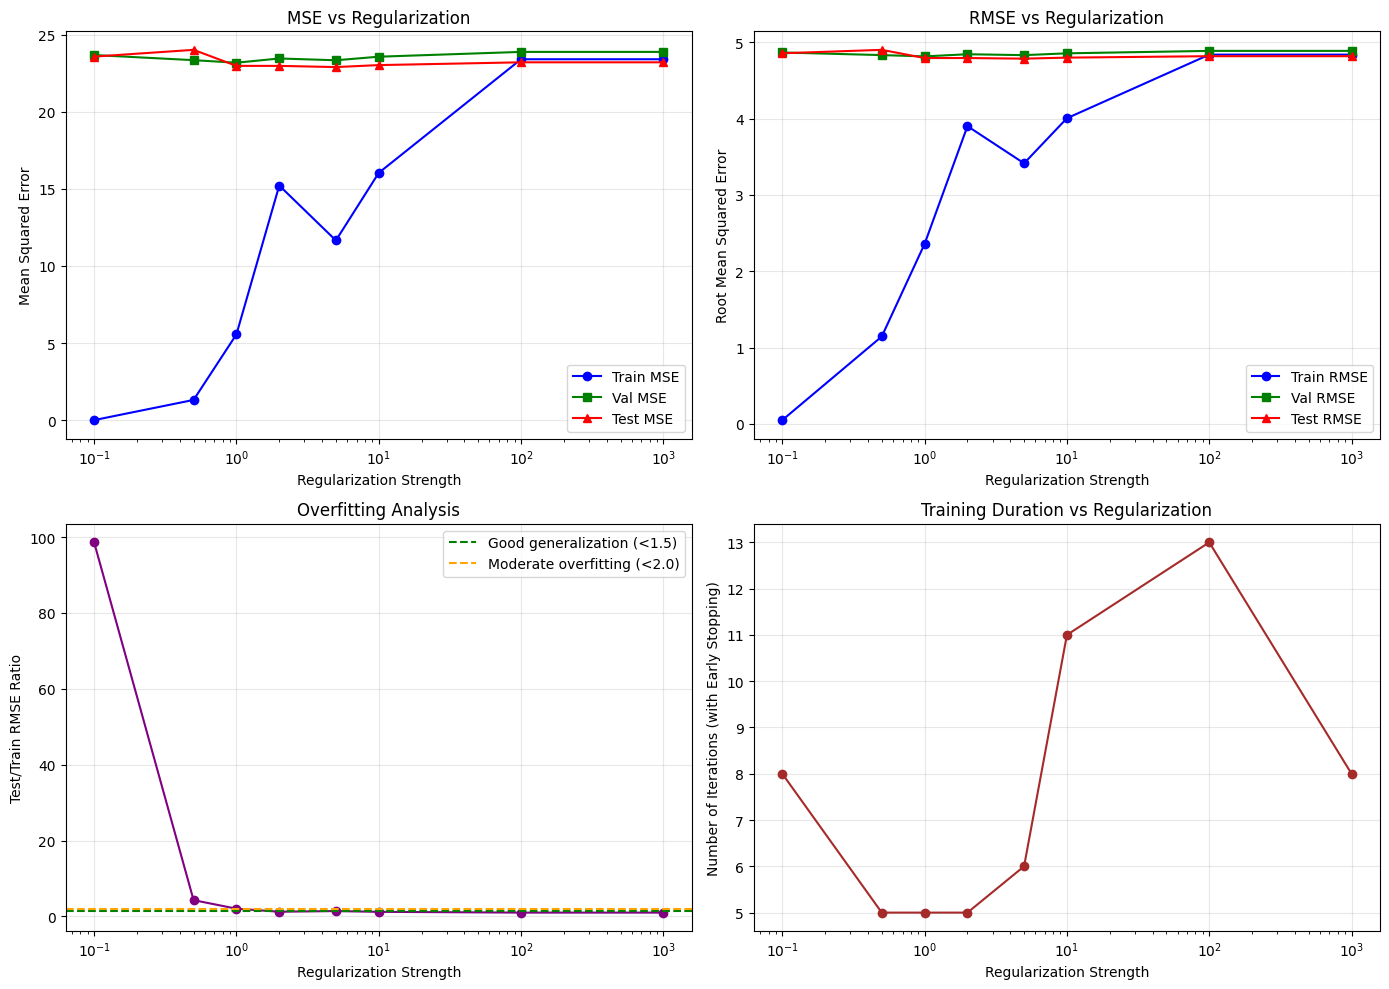

Best model based on test performance:
  Regularization: 100.0
  Test RMSE: 4.8166
  Overfitting ratio: 1.00
  ✓ Excellent generalization


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    results_df["regularization"],
    results_df["train_mse"],
    "o-",
    label="Train MSE",
    color="blue",
)
axes[0, 0].plot(
    results_df["regularization"],
    results_df["val_mse"],
    "s-",
    label="Val MSE",
    color="green",
)
axes[0, 0].plot(
    results_df["regularization"],
    results_df["test_mse"],
    "^-",
    label="Test MSE",
    color="red",
)
axes[0, 0].set_xlabel("Regularization Strength")
axes[0, 0].set_ylabel("Mean Squared Error")
axes[0, 0].set_title("MSE vs Regularization")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale("log")

axes[0, 1].plot(
    results_df["regularization"],
    results_df["train_rmse"],
    "o-",
    label="Train RMSE",
    color="blue",
)
axes[0, 1].plot(
    results_df["regularization"],
    results_df["val_rmse"],
    "s-",
    label="Val RMSE",
    color="green",
)
axes[0, 1].plot(
    results_df["regularization"],
    results_df["test_rmse"],
    "^-",
    label="Test RMSE",
    color="red",
)
axes[0, 1].set_xlabel("Regularization Strength")
axes[0, 1].set_ylabel("Root Mean Squared Error")
axes[0, 1].set_title("RMSE vs Regularization")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale("log")

overfitting_ratio = results_df["test_rmse"] / results_df["train_rmse"]
axes[1, 0].plot(results_df["regularization"], overfitting_ratio, "o-", color="purple")
axes[1, 0].axhline(
    y=1.5, color="green", linestyle="--", label="Good generalization (<1.5)"
)
axes[1, 0].axhline(
    y=2.0, color="orange", linestyle="--", label="Moderate overfitting (<2.0)"
)
axes[1, 0].set_xlabel("Regularization Strength")
axes[1, 0].set_ylabel("Test/Train RMSE Ratio")
axes[1, 0].set_title("Overfitting Analysis")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale("log")

axes[1, 1].plot(
    results_df["regularization"], results_df["n_iterations"], "o-", color="brown"
)
axes[1, 1].set_xlabel("Regularization Strength")
axes[1, 1].set_ylabel("Number of Iterations (with Early Stopping)")
axes[1, 1].set_title("Training Duration vs Regularization")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale("log")

plt.tight_layout()
plt.show()

best_idx = results_df["test_rmse/train_rmse"].idxmin()
best_reg = results_df.loc[best_idx, "regularization"]
best_test_rmse = results_df.loc[best_idx, "test_rmse"]
best_ratio = overfitting_ratio[best_idx]

print(f"Best model based on test performance:")
print(f"  Regularization: {best_reg}")
print(f"  Test RMSE: {best_test_rmse:.4f}")
print(f"  Overfitting ratio: {best_ratio:.2f}")

if best_ratio < 1.5:
    print("  ✓ Excellent generalization")
elif best_ratio < 2.0:
    print("  ⚠ Acceptable generalization")
else:
    print("  ✗ Poor generalization")

## Hyperparameter Tuning with Train/Test Evaluation

In [17]:
factors_to_test = [5, 10, 20, 30]
results = []

print("Testing different numbers of factors with train/test evaluation...")
for n_factors in factors_to_test:
    print(f"\nTraining with {n_factors} factors...")

    test_model = ExplicitALS(
        n_factors=n_factors,
        n_iterations=64,
        user_reg=5,
        item_reg=5,
        early_stopping_rounds=4,
        random_state=42,
    )

    test_model.fit(train_matrix)

    train_preds = predict_for_pairs(test_model, train_rows, train_cols)
    train_mse = mean_squared_error(train_ratings_data, train_preds)

    test_preds = predict_for_pairs(test_model, test_rows, test_cols)
    test_mse = mean_squared_error(test_ratings_data, test_preds)

    results.append(
        {
            "n_factors": n_factors,
            "train_mse": train_mse,
            "train_rmse": np.sqrt(train_mse),
            "test_mse": test_mse,
            "test_rmse": np.sqrt(test_mse),
        }
    )

    print(f"  Train MSE: {train_mse:.4f}, RMSE: {np.sqrt(train_mse):.4f}")
    print(f"  Test MSE: {test_mse:.4f}, RMSE: {np.sqrt(test_mse):.4f}")

results_df = pd.DataFrame(results)

Testing different numbers of factors with train/test evaluation...

Training with 5 factors...
Iteration 0, Train MSE: 22.4734
Iteration 5, Train MSE: 3.1744
Iteration 10, Train MSE: 3.1559
Iteration 15, Train MSE: 3.1510
Iteration 20, Train MSE: 3.1488
Iteration 25, Train MSE: 3.1478
Iteration 30, Train MSE: 3.1474
Iteration 35, Train MSE: 3.1472
Iteration 40, Train MSE: 3.1472
Iteration 45, Train MSE: 3.1472
Iteration 50, Train MSE: 3.1473
Iteration 55, Train MSE: 3.1474
Iteration 60, Train MSE: 3.1475
Iteration 63, Train MSE: 3.1476
Training completed after 64 iterations
  Train MSE: 3.1476, RMSE: 1.7742
  Test MSE: 21.3807, RMSE: 4.6239

Training with 10 factors...
Iteration 0, Train MSE: 21.6961
Iteration 5, Train MSE: 3.1635
Iteration 10, Train MSE: 3.1513
Iteration 15, Train MSE: 3.1484
Iteration 20, Train MSE: 3.1476
Iteration 25, Train MSE: 3.1475
Iteration 30, Train MSE: 3.1475
Iteration 35, Train MSE: 3.1476
Iteration 40, Train MSE: 3.1477
Iteration 45, Train MSE: 3.1479
Ite

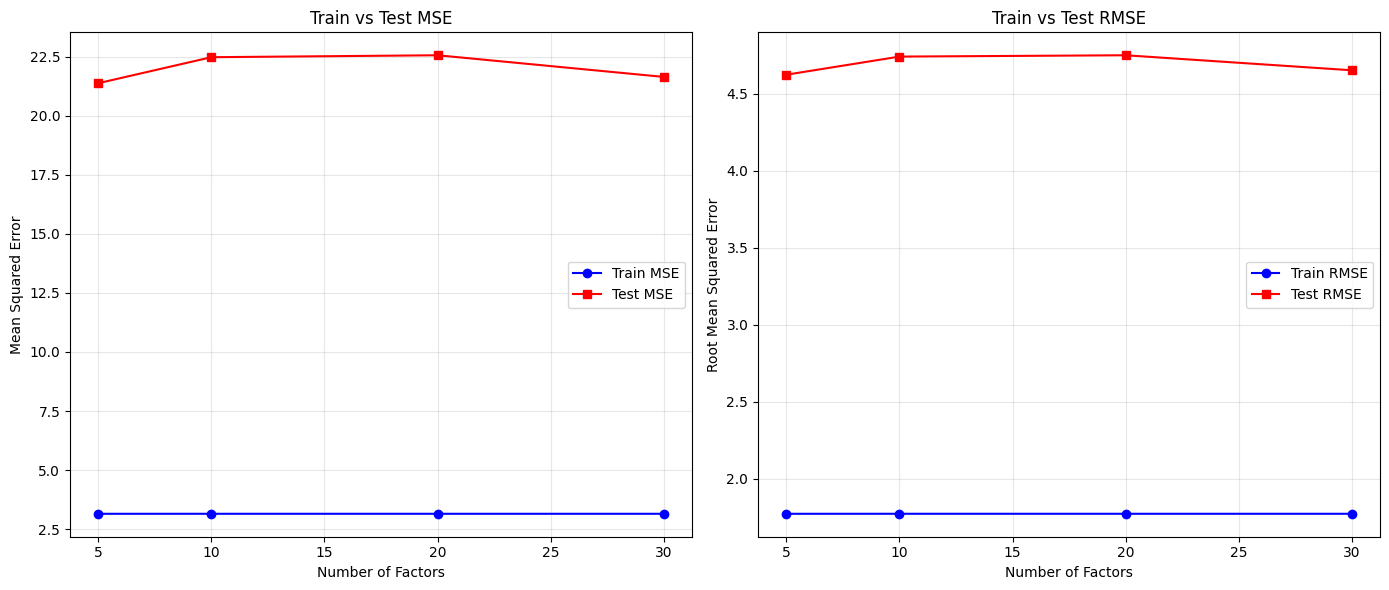

Best model based on test performance:
  Number of factors: 5
  Test RMSE: 4.6239


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(
    results_df["n_factors"],
    results_df["train_mse"],
    "o-",
    label="Train MSE",
    color="blue",
)
axes[0].plot(
    results_df["n_factors"], results_df["test_mse"], "s-", label="Test MSE", color="red"
)
axes[0].set_xlabel("Number of Factors")
axes[0].set_ylabel("Mean Squared Error")
axes[0].set_title("Train vs Test MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    results_df["n_factors"],
    results_df["train_rmse"],
    "o-",
    label="Train RMSE",
    color="blue",
)
axes[1].plot(
    results_df["n_factors"],
    results_df["test_rmse"],
    "s-",
    label="Test RMSE",
    color="red",
)
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("Root Mean Squared Error")
axes[1].set_title("Train vs Test RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = results_df["test_rmse"].idxmin()
best_n_factors = results_df.loc[best_idx, "n_factors"]
best_test_rmse = results_df.loc[best_idx, "test_rmse"]

print(f"Best model based on test performance:")
print(f"  Number of factors: {best_n_factors}")
print(f"  Test RMSE: {best_test_rmse:.4f}")

## Save Model for Future Use

In [ ]:
model_data = {
    "user_factors": model.user_factors,
    "item_factors": model.item_factors,
    "user_ids": user_ids,
    "item_ids": project_titles,
    "rated_items": rated_items,
    "train_data": {
        "rows": final_train_rows,
        "cols": final_train_cols,
        "ratings": final_train_ratings_data,
    },
    "val_data": {"rows": val_rows, "cols": val_cols, "ratings": val_ratings_data},
    "test_data": {"rows": test_rows, "cols": test_cols, "ratings": test_ratings_data},
    "model_params": {
        "n_factors": model.n_factors,
        "n_iterations": model.n_iterations,
        "user_reg": model.user_reg,
        "item_reg": model.item_reg,
        "early_stopping_rounds": model.early_stopping_rounds,
        "random_state": model.random_state,
    },
    "performance": {
        "train_mse": train_mse,
        "train_rmse": train_rmse,
        "val_mse": val_mse,
        "val_rmse": val_rmse,
        "test_mse": test_mse,
        "test_rmse": test_rmse,
        "overfitting_ratio": test_rmse / train_rmse,
    },
    "training_history": model.training_history,
}

with open("als_model_explicit.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Custom ALS model with anti-overfitting saved to custom_als_model.pkl")

Custom ALS model with anti-overfitting saved to custom_als_model.pkl
